# 02 - Descriptiva detallada y extracción de características

Este cuaderno realiza una descriptiva más profunda del dataset integrado, genera nuevas variables y construye la matriz de correlación para identificar las variables más relevantes.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

sns.set_theme(style='whitegrid')

project_root = Path(r'D:\GitHub\Ruta_aprendizaje_2024\06-Integración_con_el_Mundo_Real\Proyecto_4')
data_dir = project_root / 'data'
df = pd.read_csv(data_dir / 'yield_df.csv')
df = df.rename(columns={'Unnamed: 0': 'id'})
df = df.copy()
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
df['hg/ha_yield'] = pd.to_numeric(df['hg/ha_yield'], errors='coerce')
df['average_rain_fall_mm_per_year'] = pd.to_numeric(df['average_rain_fall_mm_per_year'], errors='coerce')
df['pesticides_tonnes'] = pd.to_numeric(df['pesticides_tonnes'], errors='coerce')
df['avg_temp'] = pd.to_numeric(df['avg_temp'], errors='coerce')
df = df.dropna(subset=['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'])

df['pesticides_log'] = np.log1p(df['pesticides_tonnes'])
df['rainfall_log'] = np.log1p(df['average_rain_fall_mm_per_year'])
df['temp_rain_interaction'] = df['avg_temp'] * df['average_rain_fall_mm_per_year']
df['year_centered'] = df['Year'] - df['Year'].mean()
df['yield_per_rain'] = df['hg/ha_yield'] / (df['average_rain_fall_mm_per_year'] + 1e-6)

print(df.head())
print(df[['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']].describe().round(2))


   id     Area         Item  Year  hg/ha_yield  average_rain_fall_mm_per_year  \
0   0  Albania        Maize  1990        36613                         1485.0   
1   1  Albania     Potatoes  1990        66667                         1485.0   
2   2  Albania  Rice, paddy  1990        23333                         1485.0   
3   3  Albania      Sorghum  1990        12500                         1485.0   
4   4  Albania     Soybeans  1990         7000                         1485.0   

   pesticides_tonnes  avg_temp  pesticides_log  rainfall_log  \
0              121.0     16.37        4.804021      7.303843   
1              121.0     16.37        4.804021      7.303843   
2              121.0     16.37        4.804021      7.303843   
3              121.0     16.37        4.804021      7.303843   
4              121.0     16.37        4.804021      7.303843   

   temp_rain_interaction  year_centered  yield_per_rain  
0               24309.45     -11.544296       24.655219  
1           

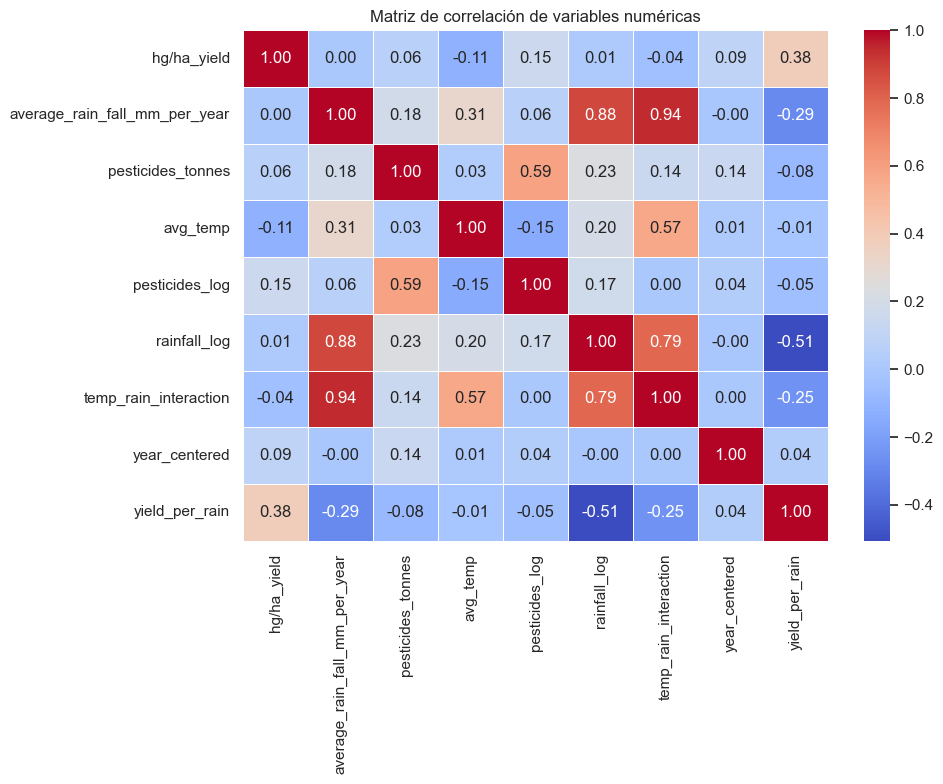

yield_per_rain                   0.378550
pesticides_log                   0.147451
year_centered                    0.091630
pesticides_tonnes                0.064085
rainfall_log                     0.013058
average_rain_fall_mm_per_year    0.000962
temp_rain_interaction           -0.044928
avg_temp                        -0.114777
Name: hg/ha_yield, dtype: float64


In [2]:
num_cols = ['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'pesticides_log', 'rainfall_log', 'temp_rain_interaction', 'year_centered', 'yield_per_rain']
correlation_matrix = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de correlación de variables numéricas')
plt.tight_layout()
plt.show()

correlations = correlation_matrix['hg/ha_yield'].drop('hg/ha_yield').sort_values(ascending=False)
print(correlations)


Item_Potatoes                    0.369454
Item_Rice, paddy                 0.074494
Item_Sweet potatoes              0.065411
Area_India                       0.057723
avg_temp                         0.046125
pesticides_log                   0.036177
pesticides_tonnes                0.035554
temp_rain_interaction            0.033211
Item_Maize                       0.027055
Item_Wheat                       0.022142
rainfall_log                     0.022021
average_rain_fall_mm_per_year    0.020124
Item_Yams                        0.020055
Item_Sorghum                     0.016799
Year                             0.016200
dtype: float64


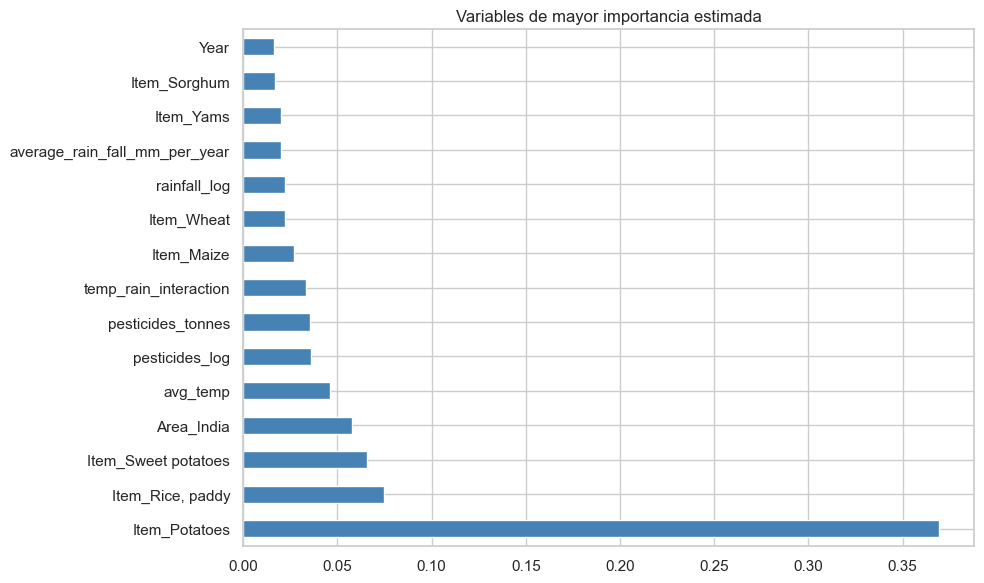

In [3]:
feature_df = pd.get_dummies(df[['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'pesticides_log', 'rainfall_log', 'temp_rain_interaction', 'year_centered']], columns=['Area', 'Item'], drop_first=True)
X = feature_df
y = df['hg/ha_yield']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
print(importances)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Variables de mayor importancia estimada')
plt.tight_layout()
plt.show()


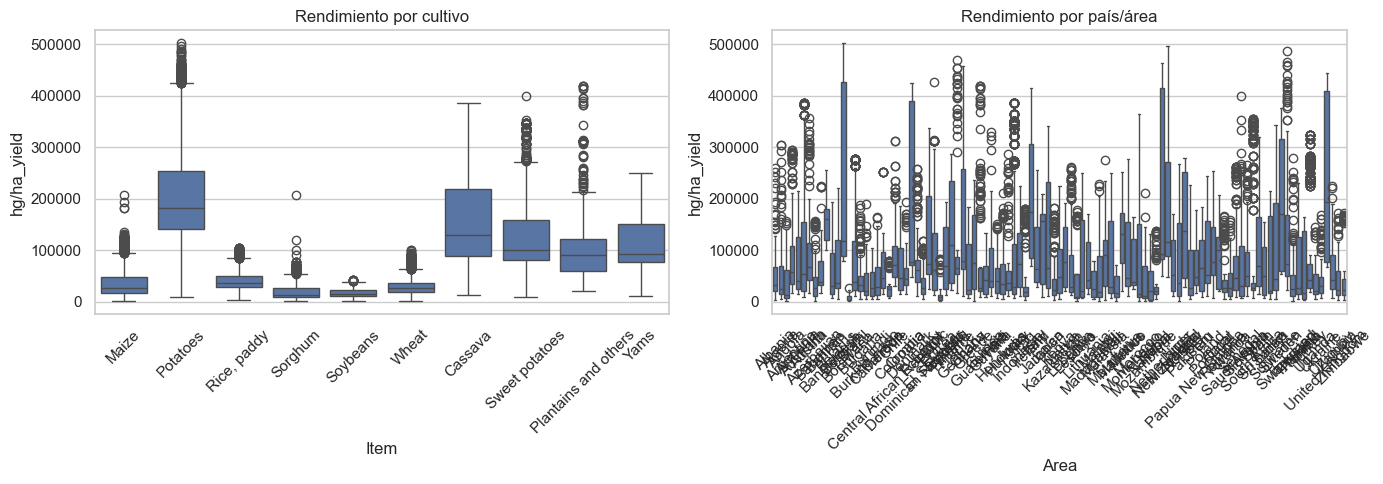

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Item', y='hg/ha_yield', ax=axes[0])
axes[0].set_title('Rendimiento por cultivo')
axes[0].tick_params(axis='x', rotation=45)
sns.boxplot(data=df, x='Area', y='hg/ha_yield', ax=axes[1])
axes[1].set_title('Rendimiento por país/área')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Variables de interés detectadas

- La precipitación y las variables derivadas de ella muestran una relación clara con el rendimiento.
- La temperatura y sus interacciones con la lluvia aportan información útil para el modelo.
- El uso de pesticidas, especialmente transformado con escala logarítmica, ayuda a estabilizar la relación con el rendimiento.
